In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv("Instagram visits clustering.csv")


In [2]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


In [4]:
df.describe()

,User ID,Instagram visit score,Spending_rank(0 to 100)
count,2600.000000,2600.000000,2600.000000
mean,1299.500000,63.323462,42.848408
std,750.699674,26.579760,28.758349
min,0.000000,5.000000,0.940709
25%,649.750000,38.000000,19.452098
50%,1299.500000,72.000000,28.013082
75%,1949.250000,86.000000,72.116945
max,2599.000000,118.000000,107.349821


In [5]:
# ==========================================
# 3. UNDERSTAND DATA
# ==========================================


df.isnull().sum()

,0
User ID,0
Instagram visit score,0
Spending_rank(0 to 100),0


In [6]:
# ==========================================
# 4. SELECT FEATURES
# ==========================================

X = df[
    [
        "Instagram visit score",
        "Spending_rank(0 to 100)"
    ]
]



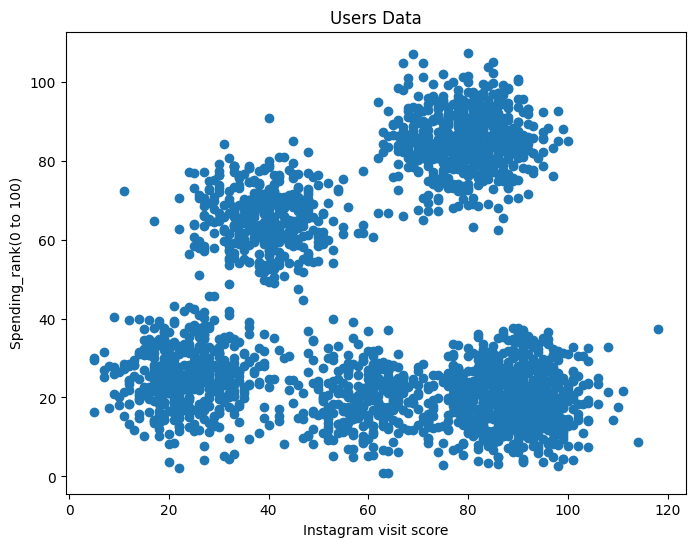

In [7]:
# ==========================================
# 5. VISUALIZE DATA
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X["Instagram visit score"],
    X["Spending_rank(0 to 100)"]
)

plt.xlabel("Instagram visit score")
plt.ylabel("Spending_rank(0 to 100)")
plt.title("Users Data")

plt.show()

In [8]:
# ==========================================
# 6. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.01217181 -0.65376894]
 [-0.08743151 -0.61298749]
 [ 1.53065202 -0.84583579]
 [ 0.70279533  1.53173941]
 [-1.85603443 -0.39495297]]


In [10]:
# ==========================================
# 7. CREATE K-MEANS MODEL
# ==========================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

In [11]:
# ==========================================
# 8. TRAIN MODEL
# ==========================================

kmeans.fit(X_scaled)

KMeans(n_clusters=2, random_state=42)

In [12]:
# ==========================================
# 9. GET CLUSTERS
# ==========================================

clusters = kmeans.labels_

print(clusters)

[0 0 0 ... 1 0 1]


In [13]:
# ==========================================
# 10. ADD CLUSTER TO DATAFRAME
# ==========================================

df["Cluster"] = clusters

df.head(10)

,User ID,Instagram visit score,Spending_rank(0 to 100),Cluster
0,0,63,24.050708,0
1,1,61,25.223290,0
2,2,104,18.528245,0
3,3,82,86.890232,1
4,4,14,31.492397,1
5,5,74,81.195314,1
6,6,83,88.119729,1
7,7,71,87.468356,1
8,8,42,80.829564,1
9,9,79,25.966622,0


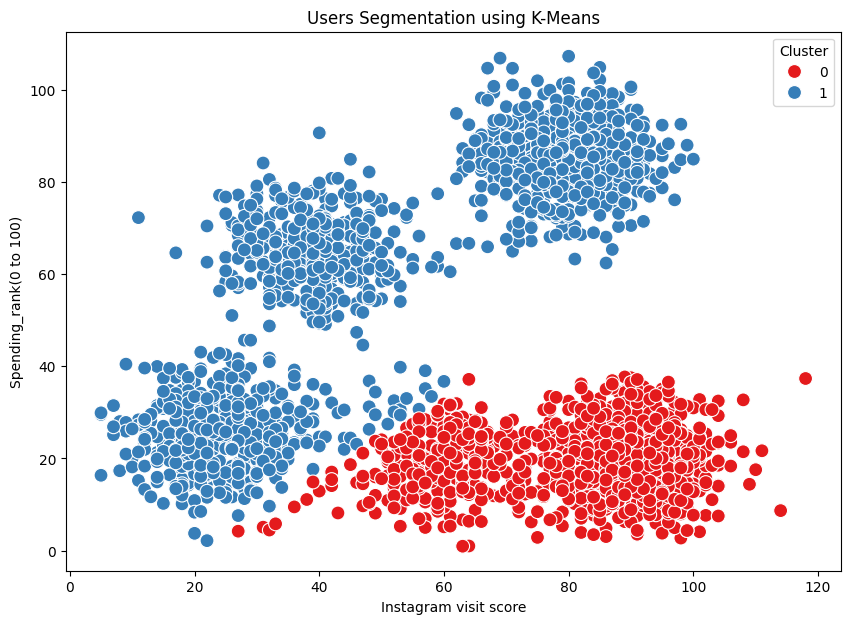

In [15]:
# ==========================================
# 11. VISUALIZE CLUSTERS
# ==========================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Instagram visit score",
    y="Spending_rank(0 to 100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Users Segmentation using K-Means")
plt.show()

In [16]:
# ==========================================
# 12. CLUSTER CENTERS
# ==========================================

centers = kmeans.cluster_centers_

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[ 0.67826316 -0.80876446]
 [-0.48652166  0.58013091]]


In [17]:
# Convert cluster centers back to original scale

centers_original = scaler.inverse_transform(centers)

print(centers_original)

[[81.3480663  19.59415048]
 [50.39431968 59.5288064 ]]


In [18]:
# ==========================================
# 13. CLUSTER CENTER TABLE
# ==========================================

centers_df = pd.DataFrame(
    centers_original,
    columns=[
        "Instagram visit score",
        "Spending_rank(0 to 100)"
    ]
)

print(centers_df)

   Instagram visit score  Spending_rank(0 to 100)
0              81.348066                19.594150
1              50.394320                59.528806
